## Titanic Survival Prediction ML Project using Random Forest

In [3]:
import pandas as pd

df = pd.read_csv('titanic.csv')

### Exploratory Data Analysis (EDA)

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.shape

(418, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [9]:
df.describe(include = 'all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [12]:
print(df.duplicated().sum())

0


In [13]:
df['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

In [16]:
print(df.select_dtypes(include = "str").columns)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


#### EDA Summary

- The dataset contains 418 passenger records and 12 features.

- There are no duplicate rows, indicating the dataset is free from duplicate entries.
- Missing values are present in the Age, Fare, and Cabin columns.
- The Cabin column contains a very large number of missing values (327), making it a candidate for removal or special preprocessing.
- The Age column has a moderate number of missing values that will require imputation.
- The target classes are slightly imbalanced, with more passengers not surviving than surviving.
- The dataset contains both numerical and categorical features.
- Categorical columns will require encoding before training a machine learning model.
- Some columns, such as PassengerId, Name, and Ticket, may not contribute significantly to prediction and will be evaluated during preprocessing.
- Further exploratory data analysis is required to study feature distributions, correlations, and relationships with the target variable.

### Preprocessing Plan

- Inspect the dataset to identify missing values, duplicate records, and data types.
- Handle missing values appropriately based on the percentage of missing data and the importance of each feature.
- Remove features that contain excessive missing values or provide little predictive information.
- Impute missing numerical values using suitable statistical measures (such as the median or mean, depending on the feature distribution).
- Encode categorical variables into numerical form so that they can be used by machine learning algorithms.
- Remove unnecessary identifier or text-based columns that do not contribute meaningfully to prediction.
- Verify that the dataset is clean and free of missing values after preprocessing.

- Prepare the processed dataset for exploratory data analysis and model training.

- Below is the plan to be applied to the following columns:

| Feature       | Decision |
| --------      | -------- |
| PassengerId   | Drop     |
| Name          | Drop     |
| Ticket        | Drop     |
| Cabin         | Drop     |
| Age           | Fill missing values with Median     |
| Fare | Drop the single missing row|
| Sex | One-Hot Encode |
| Embarked | One-Hot Encode |

### Data Preprocessing

#### 1. Drop Unnecessary Columns

In [17]:
df = df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

#### 2. Handle Missing Values

In [18]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [19]:
df = df.dropna(subset = 'Fare')

Verifying Missing Values

In [20]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

#### 3. One-Hot Encoding

First, checking which columns need Encoding.

In [21]:
df.select_dtypes(include = "str").columns

Index(['Sex', 'Embarked'], dtype='str')

Now, Encoding these columns.

In [22]:
df = pd.get_dummies(
    df, 
    columns = ['Sex', 'Embarked'],
    drop_first = True,
)

#### Final Verification

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    417 non-null    int64  
 1   Pclass      417 non-null    int64  
 2   Age         417 non-null    float64
 3   SibSp       417 non-null    int64  
 4   Parch       417 non-null    int64  
 5   Fare        417 non-null    float64
 6   Sex_male    417 non-null    bool   
 7   Embarked_Q  417 non-null    bool   
 8   Embarked_S  417 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 24.0 KB


In [24]:
df.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [25]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,True,True,False
1,1,3,47.0,1,0,7.0000,False,False,True
2,0,2,62.0,0,0,9.6875,True,True,False
3,0,3,27.0,0,0,8.6625,True,False,True
4,1,3,22.0,1,1,12.2875,False,False,True


#### Conclusion after Preprocessing

- Removed the PassengerId, Name, Ticket, and Cabin columns because they were either identifiers, contained excessive missing values, or required advanced feature engineering beyond the scope of this project.
- Missing values in the Age column were imputed using the median to reduce the influence of outliers.
- The single missing value in the Fare column was removed since it had a negligible impact on the dataset size.
- Categorical features (Sex and Embarked) were converted into numerical form using One-Hot Encoding.

- After preprocessing, the dataset contained no missing values and was fully numerical, making it suitable for exploratory data analysis and model training.

### Extensive EDA

In [26]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,417.000000,417.000000,417.000000,417.000000,417.000000,417.000000
mean,0.364508,2.263789,29.525180,0.448441,0.393285,35.627188
std,0.481870,0.842077,12.628258,0.897568,0.982419,55.907576
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.500000
max,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


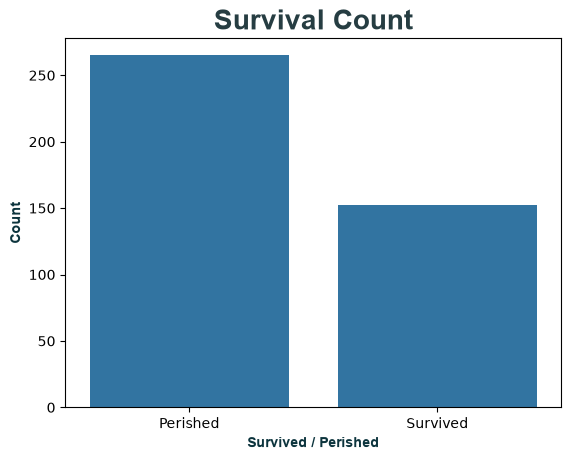

In [42]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.countplot(x = 'Survived', data = df)

plt.xticks(ticks=[0, 1], labels=["Perished", "Survived"])
plt.title('Survival Count', fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')
plt.xlabel('Survived / Perished', fontweight = "bold", family = 'Arial', color = "#0c343d")
plt.ylabel('Count', fontweight = "bold", family = 'Arial', color = "#0c343d")

plt.show()

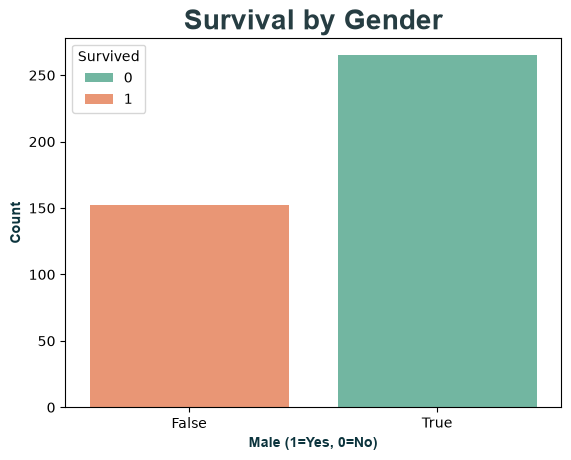

In [68]:
sns.countplot(data = df, x = 'Sex_male', hue = 'Survived', palette = 'Set2')

plt.title("Survival by Gender", fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')
plt.xlabel("Male (1=Yes, 0=No)", fontweight = "bold", family = 'Arial', color = "#0c343d")
plt.ylabel("Count", fontweight = "bold", family = 'Arial', color = "#0c343d")

plt.show()

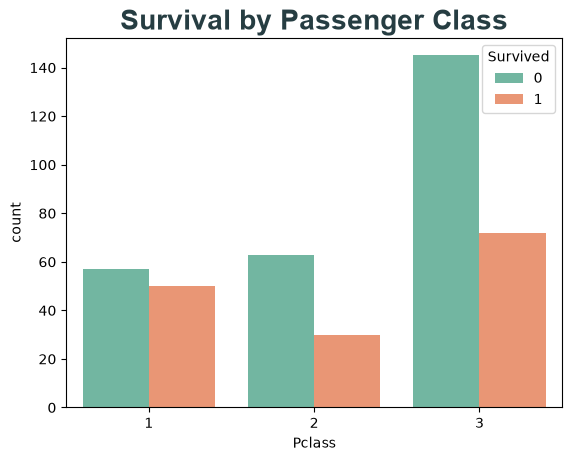

In [75]:
sns.countplot(data = df, x = 'Pclass', hue = 'Survived', palette = 'Set2')

plt.title("Survival by Passenger Class", fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.show()

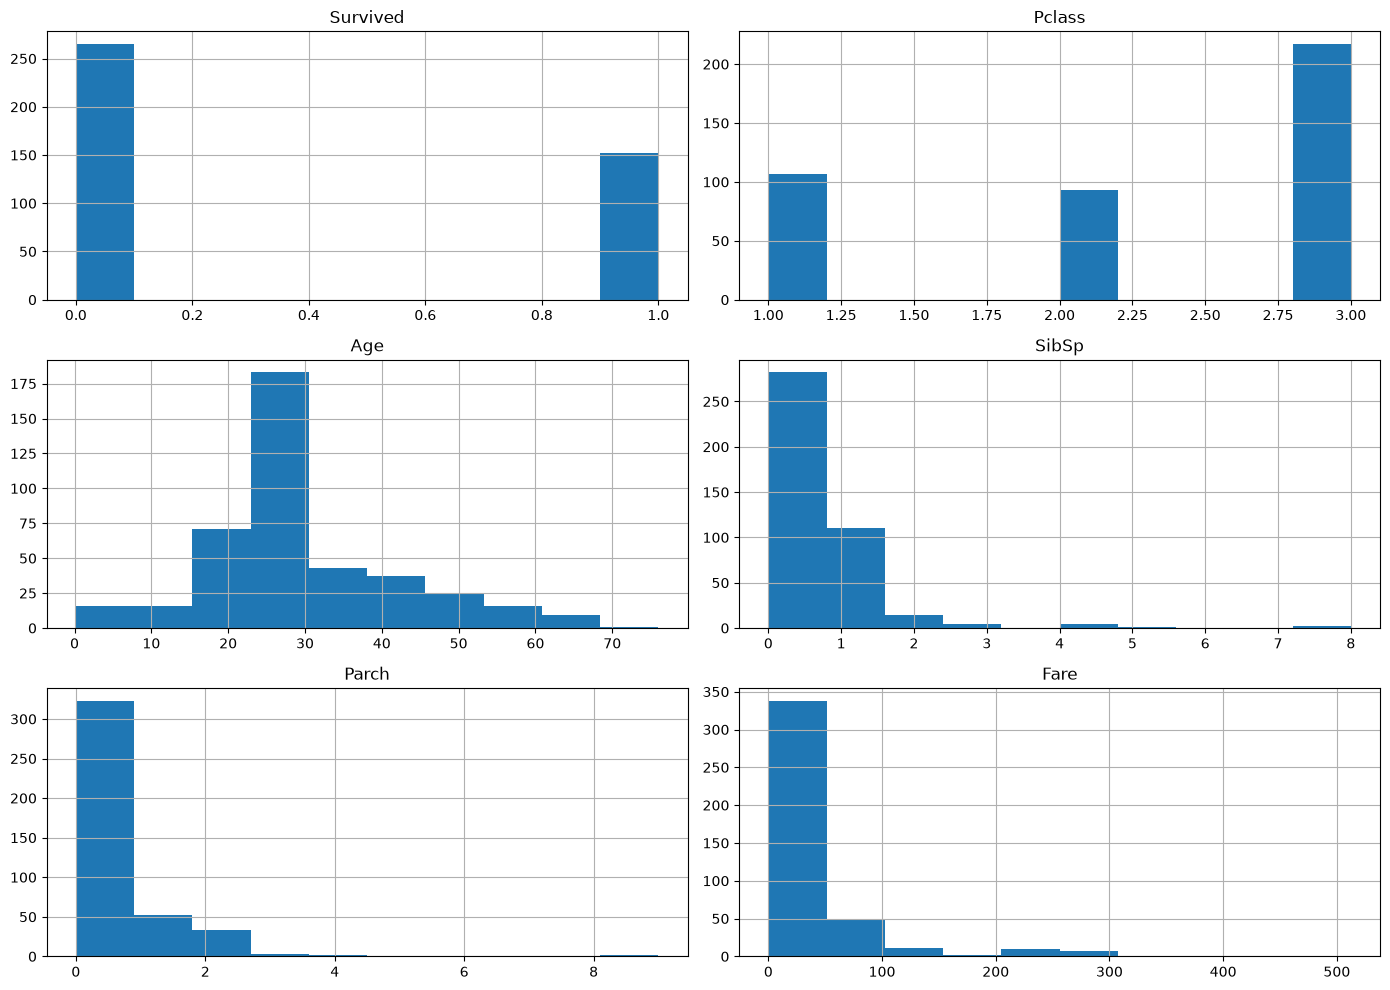

In [59]:
df.hist(
    figsize=(14,10)
)

plt.tight_layout()

plt.show()

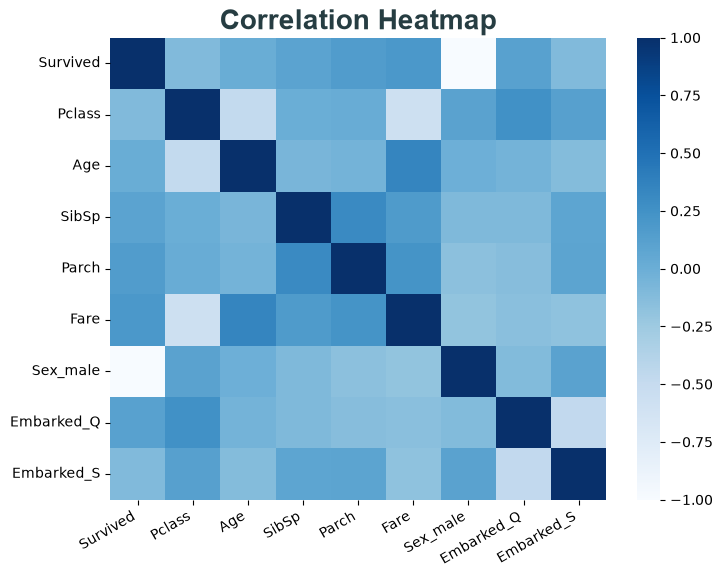

In [69]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    cmap="Blues",
    annot=False
)

plt.title('Correlation Heatmap', fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.xticks(rotation = 30, ha = 'right')

plt.show()

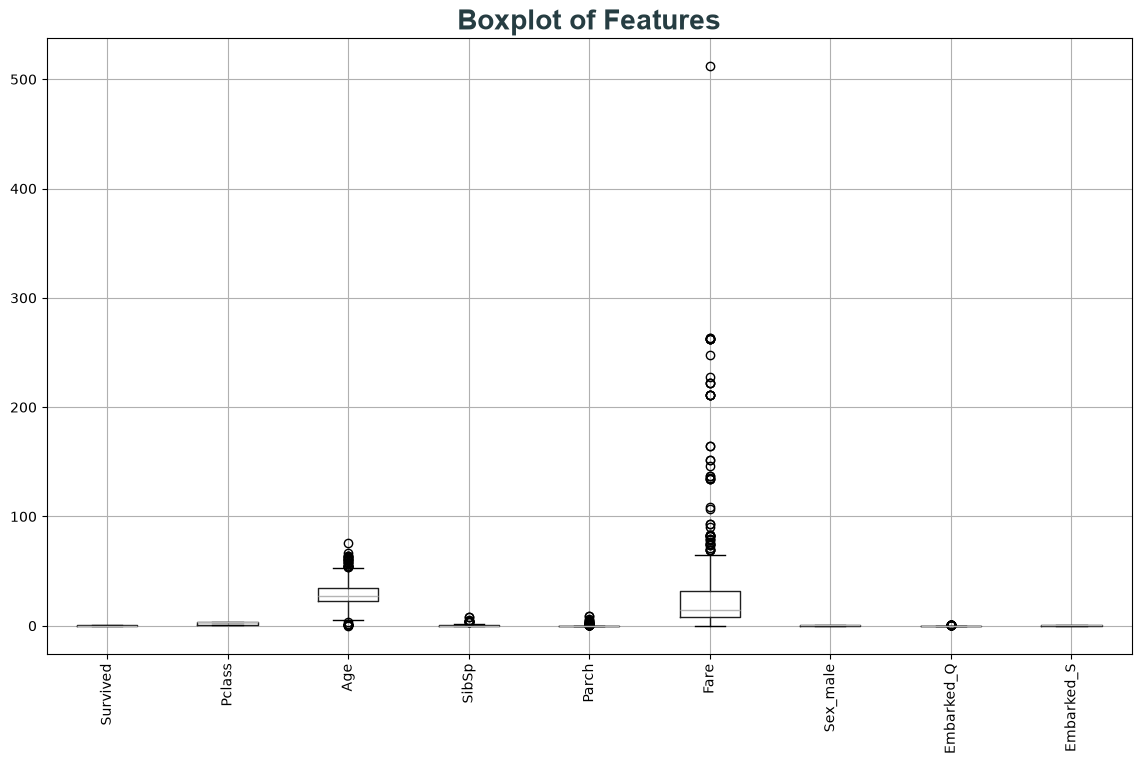

In [70]:
plt.figure(figsize=(14,8))

df.boxplot(rot=90)

plt.title('Boxplot of Features', fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.show()

#### Extensive EDA Summary

- The dataset is slightly imbalanced, with more passengers who did not survive than those who survived.
- Female passengers had a noticeably higher survival rate than male passengers.
- Passenger class appears to influence survival, with higher-class passengers generally showing better survival rates.
- Most numerical features follow reasonable distributions, although some are slightly skewed.
- The Fare feature contains several high-value outliers, while Age and Parch also exhibit a few outliers.
- The Sex_male feature has a strong negative correlation with the target variable, indicating that male passengers were less likely to survive.
- Pclass and Fare show a moderate negative correlation, suggesting that passengers in higher classes generally paid higher fares.
- No feature shows an extremely strong positive correlation with the target variable, indicating that survival depends on multiple factors rather than a single feature.

- Since Random Forest is robust to outliers and does not require feature scaling, no additional preprocessing is required before model training.

### Implementation

First, let us Create X and y from the dataset.

In [78]:
X = df.drop("Survived", axis = 1)
y = df["Survived"]

#### Train-Test Split

In [79]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

#### Model Training

Since I am working with Random Forest (Tree based model), i have skipped the Feature Scaling step.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

#### Model Prediction

In [81]:
predictions = rf.predict(x_test)

#### Evaluation

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision :", precision_score(y_test, predictions))
print("Recall :", recall_score(y_test, predictions))
print("F1 Score :", f1_score(y_test, predictions))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Confusion Matrix:

[[53  0]
 [ 0 31]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



#### Observation

- The Random Forest Classifier achieved an Accuracy of 100%, correctly classifying every test sample.
- The model obtained 100% Precision, indicating that every passenger predicted as survived was actually a survivor.
- The Recall of 100% shows that the model successfully identified all actual survivors without missing any.
- The F1-score of 100% demonstrates a perfect balance between Precision and Recall.
- The Confusion Matrix contains no False Positives and no False Negatives, indicating flawless classification on the test data.

- Overall, the baseline Random Forest model performed exceptionally well on this dataset.

### Feature Importance

Let us now observe which features are the most useful in prediction.

In [84]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

print(feature_importance)

Sex_male      0.826758
Fare          0.061834
Age           0.047196
Parch         0.021246
SibSp         0.012499
Embarked_Q    0.011760
Pclass        0.011474
Embarked_S    0.007233
dtype: float64


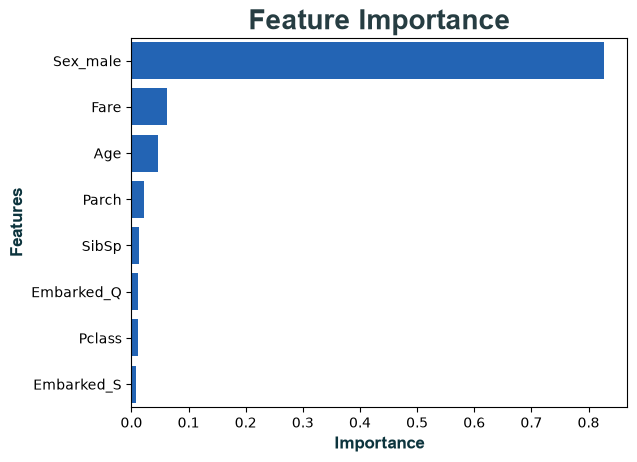

In [99]:
sns.barplot(x = feature_importance.values, y = feature_importance.index, color = "#0B62CC")

plt.title("Feature Importance", fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.xlabel("Importance", fontsize = 12, fontweight = "bold", family = 'Arial', color = "#0c343d")
plt.ylabel('Features', fontsize = 12, fontweight = "bold", family = 'Arial', color = "#0c343d")

plt.show()

#### Observation 

- The Sex_male feature was the most important predictor, contributing approximately 82.7% of the total feature importance.
- Fare and Age also contributed to the model, although their influence was much smaller than gender.
- Features such as Parch and SibSp had relatively low importance, indicating a limited contribution to the prediction.
- Embarked and Pclass received very low importance scores, suggesting that other correlated features captured similar information.

- Overall, the feature importance analysis indicates that gender was the dominant factor influencing survival predictions in the Random Forest model.

### Model Improvement - Hyperparameter Tuning using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

In [101]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
1.0


Now, let me evaluate the tuned model.

In [102]:
best_rf = grid.best_estimator_

pred = best_rf.predict(x_test)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision :", precision_score(y_test, pred))
print("Recall :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


#### Observation 

- GridSearchCV was used to search for the optimal combination of Random Forest hyperparameters using 5-fold cross-validation.
- The best hyperparameters selected by GridSearchCV were used to train the final Random Forest model.
- After hyperparameter tuning, the model achieved 100% Accuracy, Precision, Recall, and F1-score on the test dataset.
- The tuned model showed no improvement over the baseline model, indicating that the default Random Forest configuration was already sufficient for this dataset.

- This suggests that the dataset is relatively easy to classify using Random Forest, and further tuning did not provide additional performance gains.

### Conclusion

- A Random Forest Classifier was successfully developed to predict passenger survival on the Titanic dataset.
- The dataset underwent preprocessing, including missing value handling, removal of unnecessary features, and One-Hot Encoding of categorical variables.
- Exploratory Data Analysis revealed meaningful relationships between passenger characteristics and survival, particularly the strong influence of gender.
- The baseline Random Forest model achieved 100% Accuracy, Precision, Recall, and F1-score, correctly classifying all test samples.
- Feature importance analysis identified Sex_male as the most influential feature, followed by Fare and Age.
- Hyperparameter tuning using GridSearchCV did not improve the model further, indicating that the default Random Forest configuration was already well-suited for this dataset.

- Overall, the Random Forest Classifier demonstrated excellent predictive performance and effectively captured the underlying patterns in the data.

- Given below is the comparison of the Baseline and Tuned Model:

| Metric | Baseline | Tuned |
| --- | --- | --- |
| Accuracy | 1.0 | 1.0 |
| Precision | 1.0 | 1.0 |
| Recall | 1.0 | 1.0 |
| F1 Score | 1.0 | 1.0 |

### Thank You